In [42]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ['GROQ_API_KEY']:
    print("Groq API Key Set!")
else:
    raise ValueError("Groq API Key is not set!!")

Groq API Key Set!


In [43]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "openai/gpt-oss-20b")

llm.invoke("Hello!").content    

'Hello! How can I help you today?'

## **PYDANTIC LLM SCHEMA**

In [44]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

class llm_schema(BaseModel):

    funny_flag : Literal["funny", "not funny"] = Field(description="Whether the joke is funny or not")
    feedback : str = Field(description="Feedback on the joke")
     
llm_with_schema = llm.with_structured_output(llm_schema)

## **GRAPH SCHEMA**

In [45]:
from typing import TypedDict

class graph_schema(TypedDict):

    topic : str
    joke : str
    funny_flag : str
    feedback : str
    max_iterations : int

## **NODES**

In [46]:
def generate_node(state : graph_schema) -> graph_schema:

    topic = state['topic']

    if state['feedback']:
        response = llm.invoke(f"Please modify the following joke {state['joke']} based on the following feedback: {state['feedback']}")
    else:
        response = llm.invoke("Create a joke about the following topic" + topic)

    state['joke'] = response.content

    return state

In [47]:
from langchain_core.prompts import ChatPromptTemplate
def evaluate_node(state : graph_schema) -> graph_schema:

    joke = state['joke']

    iteration = state['max_iterations']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a comedy critic. Your job is to evaluate the following joke & provide feedback on how to make it funny"),
            ("human", f"Evaluate the following joke: {joke} \n Respond with 'funny' or 'not_funny' and provide feedback if it's not funny ")
        ]
    )

    chain = prompt | llm_with_schema

    response = chain.invoke({"joke": joke})

    state['funny_flag'] = response.funny_flag
    state['feedback'] = response.feedback
    state['max_iterations'] = iteration + 1

    return state

## **CONDITIONAL EDGE FUNCTION**

In [48]:
def check_iteration(state : graph_schema) -> str:

    iteration = state['max_iterations']

    if iteration <= 5 and state['funny_flag'] != "funny":
        return "evaluate_node"
    else:
        return "end"

## **STATE GRAPH**

In [49]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_conditional_edges("generate_node", check_iteration, {"evaluate_node" : "evaluate_node", "end" : END})
graph.add_edge("evaluate_node", "generate_node")
graph.add_edge("generate_node", END)

generator_graph = graph.compile()

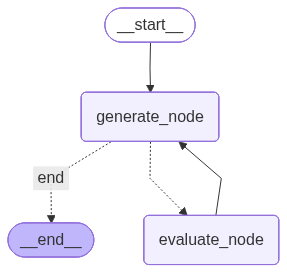

In [50]:
from IPython.display import Image, display

Image(generator_graph.get_graph().draw_mermaid_png())

## **INVOKE GRAPH**

In [51]:
for chunk in generator_graph.stream(
    {
        "topic" : "Cricket",
        "joke" : "",
        "funny_flag" : "",
        "feedback" : "",
        "max_iterations" : 0
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'Cricket', 'joke': 'Why don’t cricket teams ever play hide-and-seek?\n\nBecause good luck hiding when everyone’s always “bat‑ting” to be found!', 'funny_flag': '', 'feedback': '', 'max_iterations': 0}}
{'evaluate_node': {'topic': 'Cricket', 'joke': 'Why don’t cricket teams ever play hide-and-seek?\n\nBecause good luck hiding when everyone’s always “bat‑ting” to be found!', 'funny_flag': 'funny', 'feedback': '', 'max_iterations': 1}}
{'generate_node': {'topic': 'Cricket', 'joke': 'Why did the cricket team bring string to the match?\n\nBecause they heard they needed to *bat* around the field and wanted to *tie* the score!', 'funny_flag': 'funny', 'feedback': '', 'max_iterations': 1}}
